Porcentaje de transacciones que son devoluciones: 1.20%

--- MUESTRA VENTAS ---
IDs: <StringArray>
['3', '3', '26']
Length: 3, dtype: str
Familias: <StringArray>
['Familia C1', 'Familia T2', 'Familia C1']
Length: 3, dtype: str

--- MUESTRA POTENCIAL ---
IDs: <StringArray>
['3', '26', '30']
Length: 3, dtype: str
Familias: <StringArray>
['Anestesia', 'Anestesia', 'Anestesia']
Length: 3, dtype: str
--- TOP 5 CLIENTES CON MAYOR DEMANDA NO CAPTURADA ---
Empty DataFrame
Columns: [Id.Cliente, Familia, VentasReales, Categoria Productos, Potencial, Gap (Potencial - Real)]
Index: []


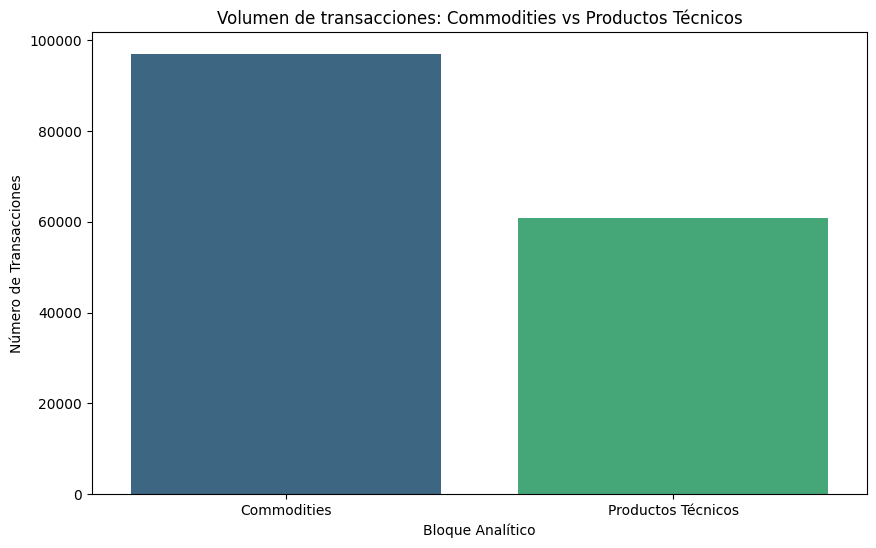

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CARGA DE DATOS (Múltiples CSVs)
# ==========================================

# Cargamos los datos. Solucionamos el DtypeWarning forzando que Num.Fact sea texto (str)
df_potencial = pd.read_csv('data/Potencial.csv', sep=',', decimal=',', thousands='.')
df_clientes = pd.read_csv('data/Clientes.csv', sep=',')
df_productos = pd.read_csv('data/Productos.csv', sep=',')
df_ventas = pd.read_csv('data/Ventas.csv', sep=',', decimal=',', thousands='.', dtype={'Num.Fact': str})
df_campanas = pd.read_csv('data/Campañas.csv', sep=',')

# Renombramos la columna vacía del CSV de clientes que se genera por las dos comas seguidas
df_clientes.rename(columns={'Unnamed: 1': 'CodigoPostal'}, inplace=True)

# ==========================================
# 2. LIMPIEZA Y PREPARACIÓN BÁSICA
# ==========================================
# Convertimos fechas
df_ventas['Fecha'] = pd.to_datetime(df_ventas['Fecha'], errors='coerce')
df_campanas['Fecha inicio'] = pd.to_datetime(df_campanas['Fecha inicio'], errors='coerce')
df_campanas['Fecha fin'] = pd.to_datetime(df_campanas['Fecha fin'], errors='coerce')

# ==========================================
# 3. CRUCES (MERGES)
# ==========================================
# Unir Ventas con Productos: en Ventas es 'Id.Producto', en Productos es 'Id.Prod'
df_ventas = df_ventas.merge(df_productos, left_on='Id.Producto', right_on='Id.Prod', how='left')

# Unir Ventas con Clientes: ambas tablas comparten ahora exactamente 'Id.Cliente'
df_ventas = df_ventas.merge(df_clientes, on='Id.Cliente', how='left')

# ==========================================
# 4. FILTRADO DE ANOMALÍAS (Devoluciones)
# ==========================================
# Separamos las ventas reales de las devoluciones o abonos que puedan distorsionar la señal [cite: 124]
devoluciones = df_ventas[df_ventas['Unidades'] < 0]
ventas_reales = df_ventas[df_ventas['Unidades'] > 0]

print(f"Porcentaje de transacciones que son devoluciones: {(len(devoluciones) / len(df_ventas)) * 100:.2f}%\n")

# ==========================================
# 5. ANÁLISIS EXPLORATORIO (EDA)
# ==========================================

# 5.1 Análisis del GAP de Potencial 
# Agrupamos cuánto compra realmente cada cliente de cada familia
# OJO: Usamos 'Id.Cliente' y 'Valores'
ventas_cliente_familia = ventas_reales.groupby(['Id.Cliente', 'Familia'])['Valores'].sum().reset_index()
ventas_cliente_familia.rename(columns={'Valores': 'VentasReales'}, inplace=True)

ventas_cliente_familia['Familia'] = ventas_cliente_familia['Familia'].str.strip()
df_potencial['Familia'] = df_potencial['Familia'].str.strip()

# Asegurar que Id.Cliente sea del mismo tipo en ambas (ej. string)
ventas_cliente_familia['Id.Cliente'] = ventas_cliente_familia['Id.Cliente'].astype(str)
df_potencial['Id.Cliente'] = df_potencial['Id.Cliente'].astype(str)

# DIAGNÓSTICO: Ver exactamente qué tienen las columnas antes de cruzar
print("--- MUESTRA VENTAS ---")
print("IDs:", ventas_cliente_familia['Id.Cliente'].head(3).values)
print("Familias:", ventas_cliente_familia['Familia'].head(3).values)

print("\n--- MUESTRA POTENCIAL ---")
print("IDs:", df_potencial['Id.Cliente'].head(3).values)
print("Familias:", df_potencial['Familia'].head(3).values)

# Cruzamos con el dataset de potencial
df_gap = pd.merge(ventas_cliente_familia, df_potencial, on=['Id.Cliente', 'Familia'], how='inner')

# Calculamos cuánto nos están dejando de comprar frente a su potencial estimado [cite: 89]
df_gap['Gap (Potencial - Real)'] = df_gap['Potencial'] - df_gap['VentasReales']

print("--- TOP 5 CLIENTES CON MAYOR DEMANDA NO CAPTURADA ---")
print(df_gap.sort_values(by='Gap (Potencial - Real)', ascending=False).head(5))

# 5.2 Gráfico Rápido: Distribución de ventas por categoría
plt.figure(figsize=(10, 6))
# OJO: Usamos 'Bloque analítico' con espacio, como en el CSV
sns.countplot(data=ventas_reales, x='Bloque analítico', hue='Bloque analítico', legend=False, palette='viridis')
plt.title('Volumen de transacciones: Commodities vs Productos Técnicos')
plt.xlabel('Bloque Analítico')
plt.ylabel('Número de Transacciones')
plt.show()


Analizando al cliente TOP: 36492

Resumen de días entre compras para el cliente 36492 en Familia T1:
count    906.000000
mean       1.998896
std        3.870129
min        0.000000
25%        0.000000
50%        0.000000
75%        2.000000
max       41.000000
Name: Dias_Desde_Ultima_Compra, dtype: float64


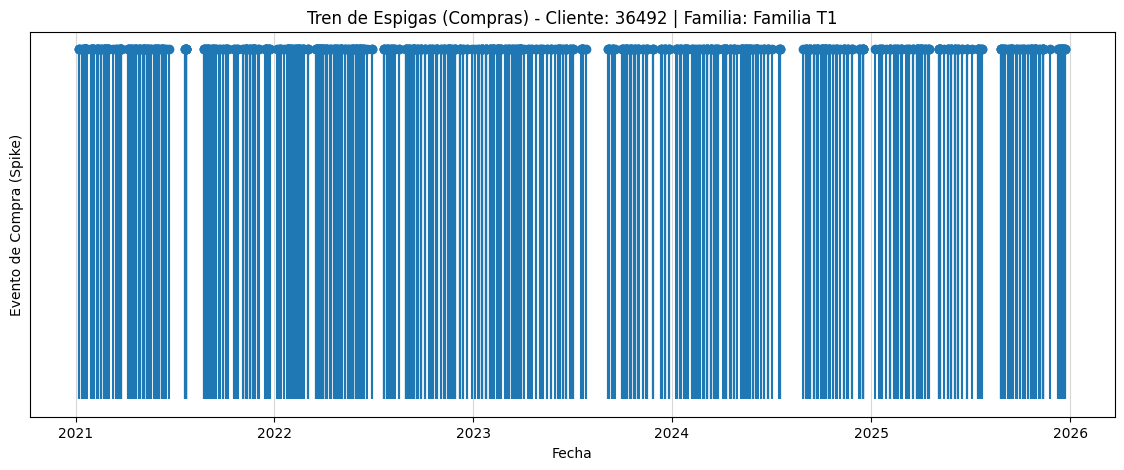

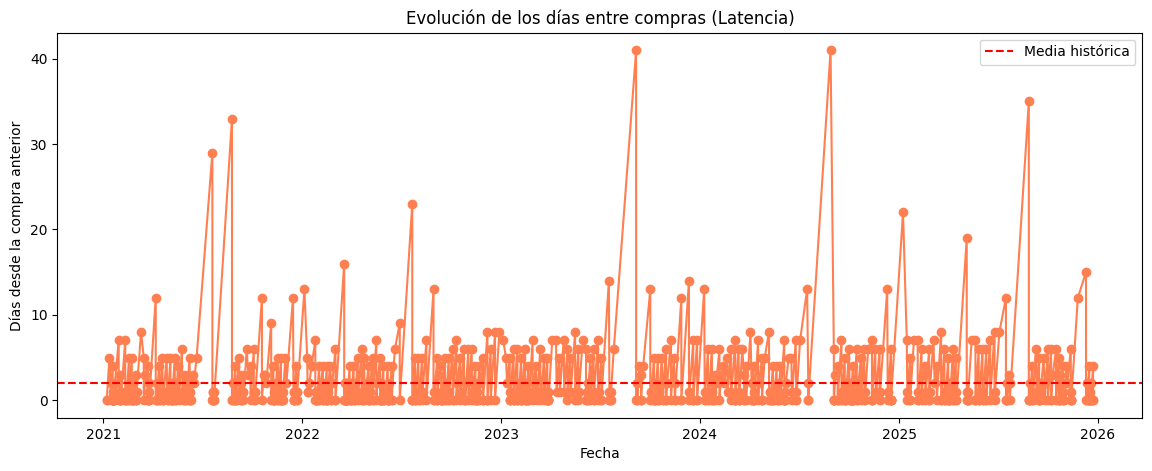

In [18]:
import numpy as np

# 1. Seleccionar al cliente con más transacciones para tener un buen ejemplo
top_cliente = ventas_reales['Id.Cliente'].value_counts().index[0]
print(f"\nAnalizando al cliente TOP: {top_cliente}")

# 2. Aislar sus datos y ordenarlos por fecha
df_un_cliente = ventas_reales[ventas_reales['Id.Cliente'] == top_cliente].copy()
df_un_cliente = df_un_cliente.sort_values('Fecha')

# 3. Calcular el "Delta Temporal" (Días desde la última compra)
# Solo podemos hacer esto con sentido si separamos por Familia de producto
# Vamos a coger la familia que más compra este cliente
top_familia = df_un_cliente['Familia'].value_counts().index[0]
df_cliente_familia = df_un_cliente[df_un_cliente['Familia'] == top_familia].copy()

# diff() calcula la diferencia con la fila anterior
df_cliente_familia['Dias_Desde_Ultima_Compra'] = df_cliente_familia['Fecha'].diff().dt.days

print(f"\nResumen de días entre compras para el cliente {top_cliente} en {top_familia}:")
print(df_cliente_familia['Dias_Desde_Ultima_Compra'].describe())

# ==========================================
# VISUALIZACIÓN: EL "SPIKE TRAIN" (Tren de Espigas)
# ==========================================
plt.figure(figsize=(14, 5))

# Usamos un stem plot (gráfico de tallos) porque simula perfectamente los 'spikes' neuronales
plt.stem(df_cliente_familia['Fecha'], 
         np.ones(len(df_cliente_familia)), 
         linefmt='C0-', markerfmt='C0o', basefmt=" ")

plt.title(f'Tren de Espigas (Compras) - Cliente: {top_cliente} | Familia: {top_familia}')
plt.xlabel('Fecha')
plt.ylabel('Evento de Compra (Spike)')
plt.yticks([]) # Quitamos el eje Y porque solo nos importa la ocurrencia temporal
plt.grid(axis='x', alpha=0.5)
plt.show()

# Visualizar la evolución del Delta Temporal
plt.figure(figsize=(14, 5))
plt.plot(df_cliente_familia['Fecha'], df_cliente_familia['Dias_Desde_Ultima_Compra'], marker='o', linestyle='-', color='coral')
plt.title(f'Evolución de los días entre compras (Latencia)')
plt.xlabel('Fecha')
plt.ylabel('Días desde la compra anterior')
plt.axhline(df_cliente_familia['Dias_Desde_Ultima_Compra'].mean(), color='red', linestyle='--', label='Media histórica')
plt.legend()
plt.show()

/tmp/ipykernel_18885/3011122697.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cliente_familia, x='Mes', y='Dias_Desde_Ultima_Compra', palette='viridis')


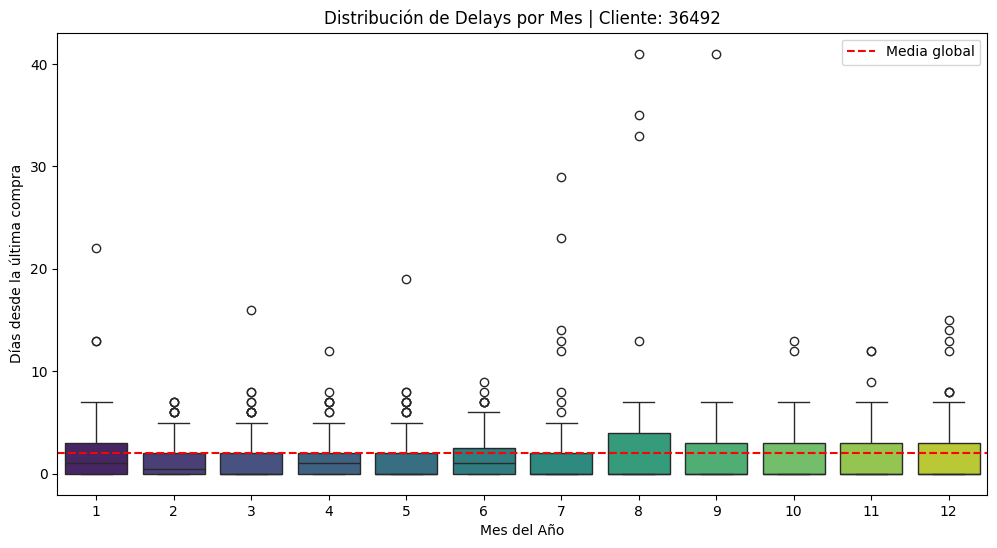

In [19]:
# Extraer el mes de la compra
df_cliente_familia['Mes'] = df_cliente_familia['Fecha'].dt.month

# Visualizar la distribución de los retrasos (delays) por mes
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_cliente_familia, x='Mes', y='Dias_Desde_Ultima_Compra', palette='viridis')
plt.title(f'Distribución de Delays por Mes | Cliente: {top_cliente}')
plt.xlabel('Mes del Año')
plt.ylabel('Días desde la última compra')
plt.axhline(df_cliente_familia['Dias_Desde_Ultima_Compra'].mean(), color='red', linestyle='--', label='Media global')
plt.legend()
plt.show()

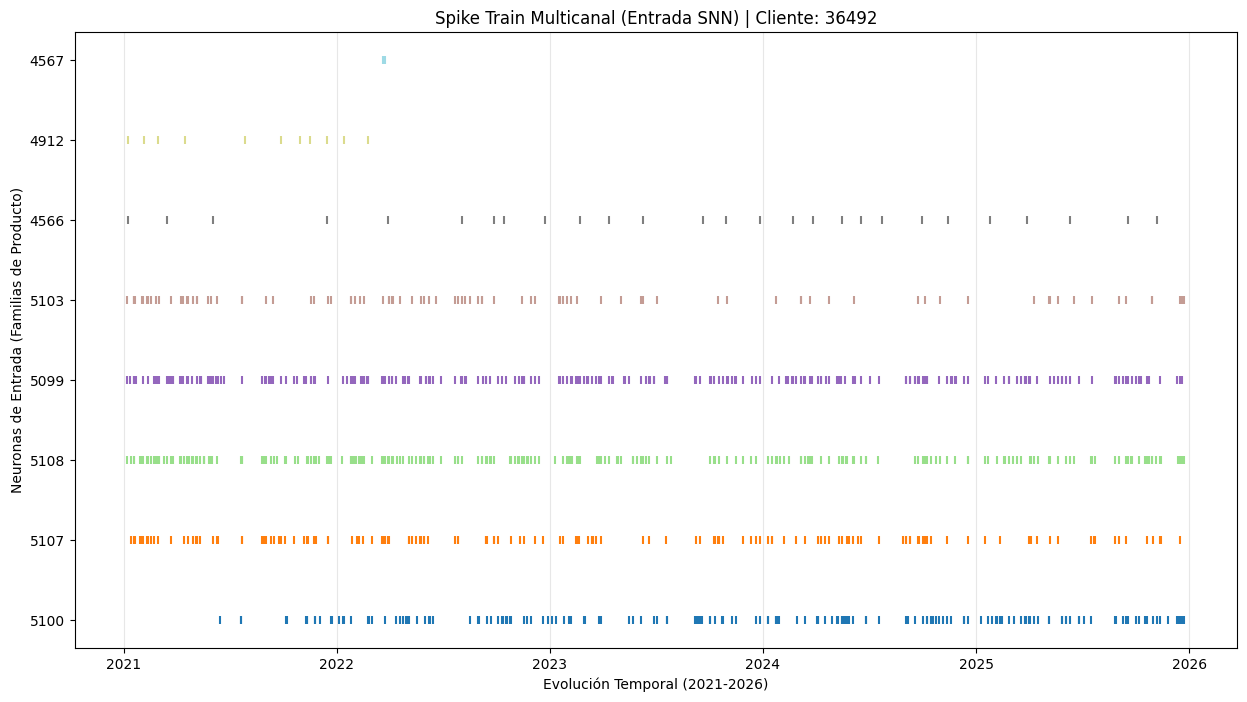

In [21]:
# 1. Obtener todos los productos comprados por este cliente
df_multi = ventas_reales[ventas_reales['Id.Cliente'] == top_cliente].copy()

# 2. Asegurarnos de tener una columna para el eje Y (Producto)
# Usamos 'Familia' para que sea más legible, pero podéis usar 'Id.Producto'
productos_ordenados = df_multi['Id.Producto'].unique()
producto_to_id = {prod: i for i, prod in enumerate(productos_ordenados)}
df_multi['Y_Axis'] = df_multi['Id.Producto'].map(producto_to_id)

# 3. Graficar el Spike Train Multicanal
plt.figure(figsize=(15, 8))
scatter = plt.scatter(df_multi['Fecha'], df_multi['Y_Axis'], 
            c=df_multi['Y_Axis'], cmap='tab20', s=30, marker='|')

plt.yticks(range(len(productos_ordenados)), productos_ordenados)
plt.title(f'Spike Train Multicanal (Entrada SNN) | Cliente: {top_cliente}')
plt.xlabel('Evolución Temporal (2021-2026)')
plt.ylabel('Neuronas de Entrada (Familias de Producto)')
plt.grid(True, axis='x', alpha=0.3)
plt.show()